In [1]:
%load_ext autoreload
%autoreload 2


# 06b — Barycenter Baseline Comparison (faithful G=28, embedding-level)

Reproduces the paper's `tab:baselines` on the **faithful representation**: full-length,
embedding-level symbolic sequences (one symbol per VideoMAE timestep, median **L≈5162**,
**G=28** category vocabulary), loaded through the same lineage as NB06c/06d via
`vocab.load_g28_cohort()`. This replaces the earlier version, which read a frozen June-6
artifact (`X_aeon.npy`, L=64, G=77 K-space) that no notebook regenerated — see
`RESULTS_HANDOFF_barycenters.md` §26 and `PAPER_TODO` §3.6.

Each method builds its barycenter on the training split only and classifies test sequences
by its **own native distance** through the shared harness `evaluate_baselines`
(`smartflat/features/symbolic_barycenter/evaluation.py`; the `baselines` module is now a
back-compat re-export shim — RH §23):

| Method | Barycenter | Native distance |
|--------|-----------|-----------------|
| **TW-TWE + mode-DBA + p_match** (proposed) | per-aligned-position mode | −p_match (rTWE + Wasserstein `D_G`) |
| TW-TWE + mode-DBA (rTWE dist) | same mode barycenter | rTWE + Wasserstein `D_G` |
| TW-TWE + mean-DBA (aeon) | aeon petitjean TWE-DBA | rTWE + Wasserstein `D_G` |
| TWE (ordinal cost) — ablation | same mode barycenter | rTWE + ordinal `|i−j|` cost |
| Edit-distance median | `barycenter_edit_median` | Levenshtein |
| Wasserstein barycenter | `barycenter_wasserstein` | EMD between histograms |
| k-Medoid (TW-TWE) | medoid of pairwise rTWE | rTWE + `D_G` |
| Majority voting | per-step mode | Hamming |
| DBA + standard DTW *(preview)* | `barycenter_dba_dtw` | DTW on `D_G` embedding |
| Soft-DTW barycenter *(preview)* | `barycenter_soft_dtw` | Soft-DTW on `D_G` embedding |

The proposed and ablation methods share one barycenter and differ only in the scoring
ground cost — isolating the Wasserstein contribution (sanity gate below).

**Length policy.** Shipped canonical constants `nu=1e-4, lmbda=0.1, offset=0.3` (`RTWE_NU` /
`RTWE_LMBDA` in `distances.py`, RH §22 — *not* the thesis grid value, which is `nu=1e-5`;
PAPER_BRIDGE §6). The load-bearing roster
(mode-DBA family, edit-median, Wasserstein, k-medoid, majority-voting) runs at the **full
median length L=5162**, made practical by the process-parallel `evaluate_baselines`
(`n_jobs`): each barycenter build is single-threaded, but the 10×3 = 30 (split×init) work units
are embarrassingly parallel. The two **pure-Python DTW baselines** (`dba_dtw`, `soft_dtw`) are
O(L²) (probe-measured L^2.1 / L^2.0) and intractable at the full length, so a **budget-gate** cell
resolves the largest length each can run under a wall-clock cap (→ `dba_dtw` L=256, `soft_dtw` L=128); their table cells are annotated `preview (L=…)` (mixed-length,
explicit). Every output row carries an `L` column.

**Protocol:** 10 random 50/50 stratified splits × 3 inits; AUC-ROC per pairwise comparison,
plus a pooled **Patient-vs-Control** pass. Significance: paired Wilcoxon signed-rank +
Benjamini-Hochberg (reference = the proposed `tw_twe_pmatch`).

**Prerequisites:** the G=28 cohort cache `g28/g28_full_with_cat.pkl` (built by NB06c or rebuilt
on cache-miss inside `load_g28_cohort`).

In [ ]:
import os
os.environ.setdefault('NUMBA_THREADING_LAYER', 'workqueue')   # hardened-kernel large-L safety (mirrors 06c/06d)
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import BoundaryNorm, ListedColormap
from IPython.display import display
from sklearn.model_selection import StratifiedShuffleSplit

from aeon.clustering.averaging import elastic_barycenter_average

from smartflat.utils.utils_io import get_data_root
from smartflat.utils.utils import upsample_sequence
from smartflat.utils.utils_visualization import get_base_colors, plot_chronogames
from smartflat.engine.distances._rtwe import rtwe_pairwise_distance
from smartflat.features.symbolic_barycenter import vocab
from smartflat.features.symbolic_barycenter.baselines import (
    evaluate_baselines,
    default_baseline_methods,
    dist_rtwe,
    dist_neg_pmatch,
    ordinal_cost_matrix,
    make_patient_control_labels,
    baseline_significance_tests,
    barycenter_mode_dba,
    barycenter_dba_dtw,
    barycenter_soft_dtw,
    barycenter_edit_median,
    barycenter_wasserstein,
    barycenter_majority_voting,
)

%matplotlib inline

# --- Thesis-canonical constants (RTWE_NU / RTWE_LMBDA in distances.py; offset per §12/§13) ---
NU, LMBDA, OFFSET = 1e-4, 0.1, 0.3
FULL_L = 5162          # full median embedding length (the faithful representation)
FIG_L = 1500           # chronogram render width (a rendering choice; underlying rep is full-length)
N_SPLITS, N_INITS = 10, 3
N_JOBS = min(N_SPLITS * N_INITS, os.cpu_count())   # parallelise the 30 (split x init) work units
print(f'nu={NU:g} lmbda={LMBDA:g} offset={OFFSET:g} | FULL_L={FULL_L} | n_jobs={N_JOBS} of {os.cpu_count()} cores')


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/aeon/base/__init__.py:24: FutureWarning: The aeon package will soon be releasing v1.0.0 with the removal of legacy modules and interfaces such as BaseTransformer and BaseForecaster. This will contain breaking changes. See aeon-toolkit.org for more information. Set aeon.AEON_DEPRECATION_WARNING or the AEON_DEPRECATION_WARNING environmental variable to 'False' to disable this warning.
  warnings.warn(


nu=0.0001 lmbda=0.1 offset=0.3 | FULL_L=5162 | n_jobs=30 of 96 cores


In [ ]:
# Faithful G=28 embedding-level cohort (median L≈5162) — SAME lineage as NB06c/06d.
data_root = get_data_root()
out_dir = os.path.join(data_root, 'outputs', 'symbolic_barycenter', 'g28')
os.makedirs(out_dir, exist_ok=True)

df, X_full, labels = vocab.load_g28_cohort()               # ragged full-length int sequences
D_G = vocab.build_g28_ground_cost(offset_value=OFFSET)     # 28×28 rTWE ground cost (offset/normalized)
D_ord = ordinal_cost_matrix(G := D_G.shape[0])             # ordinal |i-j| cost for the ablation
code = json.load(open(os.path.join(out_dir, 'category_codes.json')))   # category name -> int (0..27)

lens = pd.Series([len(s) for s in X_full])
# REPRESENTATION GATE (mandate): must be embedding-level, not segment-level (~177) or L=64 K-space.
assert lens.median() > 1000, f'sequences are not embedding-level (median L={lens.median():.0f})'
assert G == 28, f'expected G=28 category vocabulary, got {G}'
allmin = min(int(np.asarray(s).min()) for s in X_full)
allmax = max(int(np.asarray(s).max()) for s in X_full)
assert allmin >= 0 and allmax < G, (allmin, allmax, G)

def Xat(L):
    """Upsample every full-length sequence to common length L, stack -> (n, L) int array."""
    return np.vstack([upsample_sequence(np.asarray(s), L) for s in X_full]).astype(int)

pooled_labels = make_patient_control_labels(labels)
print(f'cohort n={len(df)}  G={G}  median L={lens.median():.0f} (min {lens.min()}, max {lens.max()})')
print(f'symbols in [{allmin}, {allmax}]  |  groups: {dict(zip(*np.unique(labels, return_counts=True)))}')
print(f'pooled: {dict(zip(*np.unique(pooled_labels, return_counts=True)))}')


cohort n=120  G=28  median L=5170 (min 2292, max 9570)
symbols in [0, 27]  |  groups: {'HEALTHY': 24, 'RIL': 37, 'TBI': 59}
pooled: {'CONTROL': 24, 'PATIENT': 96}


### Tier B — load-bearing roster at full length (L=5162)

Each method builds its barycenter on the training split only and classifies test sequences
by nearest-group barycenter under its **own native distance** (no leakage; enforced inside
`evaluate_baselines`). We run a pairwise pass (Control / RIL / TBI) and a pooled pass
(Patient vs Control), then concatenate. AUC-ROC is reported as mean ± std over splits × inits.

The one-time pairwise rTWE matrix (`k_medoid`'s cost) is ~40 s at L=5162 (measured, this run). The
mode-DBA family and edit-median are O(L²); with `n_jobs` the 30 (split×init) units finish in **~3.2 h
wall** (mode-DBA ~90 s/build at L=5162, edit-median ~270 s/build, under concurrent load — RH §26). The pure-Python `dba_dtw`/`soft_dtw` are handled separately by the
budget gate in the next cell.

In [ ]:
QUICK_MODE = os.environ.get('NB06B_QUICK', '0') == '1'   # NB06B_QUICK=1 -> L=256, 2x1 smoke test

# --- Method registry: default baselines + proposed variants + ablation ---
# dba_dtw & soft_dtw stay in `methods` (their native distances are reused by the budget gate),
# but they are excluded from TIER_B and handled at a gated preview length in the next cell.
methods = dict(default_baseline_methods(D_G, nu=NU, lmbda=LMBDA))

def build_mode(X_grp, seed):
    """Categorical mode-based DBA (per-aligned-position majority) — the paper's symbolic
    'mode update' barycenter. Matches NB06c's tw_twe_mode build."""
    return barycenter_mode_dba(X_grp, D_G, nu=NU, lmbda=LMBDA, random_state=seed)

def build_mean(X_grp, seed):
    """aeon mean-based TWE-DBA (averages nominal symbol indices) — documents the categorical
    degeneracy of a continuous barycenter on symbolic data (not load-bearing)."""
    Xa = X_grp.astype(np.float64)[:, None, :]
    b = elastic_barycenter_average(Xa, method='petitjean', distance='twe', nu=NU, lmbda=LMBDA,
                                   init_barycenter='random', max_iters=10, tol=1e-5, random_state=seed)
    return np.clip(np.rint(np.asarray(b).squeeze()).astype(int), 0, G - 1)

# Proposed method + variants. tw_twe_pmatch (mode-DBA + p_match) is the faithful proposed method;
# tw_twe (same barycenter, rTWE distance with D_G) and twe_ablation (same barycenter, ordinal cost)
# form the Wasserstein-isolation sanity gate.
methods['tw_twe_pmatch'] = {'build': build_mode, 'distance': lambda s, b: dist_neg_pmatch(s, b, D_G, nu=NU, lmbda=LMBDA)}
methods['tw_twe']        = {'build': build_mode, 'distance': lambda s, b: dist_rtwe(s, b, D_G, nu=NU, lmbda=LMBDA)}
methods['tw_twe_mean']   = {'build': build_mean, 'distance': lambda s, b: dist_rtwe(s, b, D_G, nu=NU, lmbda=LMBDA)}
methods['twe_ablation']  = {'build': build_mode, 'distance': lambda s, b: dist_rtwe(s, b, D_ord, nu=NU, lmbda=LMBDA)}

TIER_B = ['tw_twe_pmatch', 'tw_twe', 'tw_twe_mean', 'twe_ablation',
          'k_medoid', 'wasserstein', 'majority_voting', 'edit_median']

L_B = 256 if QUICK_MODE else FULL_L
sp, ni = (2, 1) if QUICK_MODE else (N_SPLITS, N_INITS)

print(f'Tier B @ L={L_B} ({sp}x{ni}, n_jobs={N_JOBS}) — building pairwise rTWE matrix...', flush=True)
t0 = time.perf_counter()
X_B = Xat(L_B)
D_pw = rtwe_pairwise_distance(X_B, nu=NU, lmbda=LMBDA, precomputed_distances=D_G)
print(f'  pairwise rTWE {D_pw.shape} in {time.perf_counter()-t0:.0f}s; running {len(TIER_B)} methods...', flush=True)

sub = {k: methods[k] for k in TIER_B}
t0 = time.perf_counter()
r1 = evaluate_baselines(X_B, labels,        sub, D_pairwise=D_pw, n_splits=sp, n_inits=ni, random_state=42, n_jobs=N_JOBS)
r2 = evaluate_baselines(X_B, pooled_labels, sub, D_pairwise=D_pw, n_splits=sp, n_inits=ni, random_state=42, n_jobs=N_JOBS)
df_B = pd.concat([r1, r2], ignore_index=True); df_B['L'] = L_B
print(f'  Tier B done in {time.perf_counter()-t0:.0f}s -> {len(df_B)} rows', flush=True)
display(df_B.groupby(['method', 'comparison'])['auc'].agg(['mean', 'std', 'count']).round(3))


Tier B @ L=5162 (10x3, n_jobs=30) — building pairwise rTWE matrix...
  pairwise rTWE (120, 120) in 40s; running 8 methods...


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/ot/bregman/_barycenter.py:250: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/ot/bregman/_barycenter.py:250: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/ot/bregman/_barycenter.py:250: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/ot/bregman/_barycenter.py:250: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `

  Tier B done in 11540s -> 960 rows


mean    std  count
method          comparison                             
edit_median     CONTROL_vs_PATIENT  0.685  0.081     30
                HEALTHY_vs_RIL      0.783  0.083     30
                HEALTHY_vs_TBI      0.690  0.062     30
                RIL_vs_TBI          0.552  0.094     30
k_medoid        CONTROL_vs_PATIENT  0.715  0.049     30
                HEALTHY_vs_RIL      0.730  0.085     30
                HEALTHY_vs_TBI      0.648  0.097     30
                RIL_vs_TBI          0.550  0.088     30
majority_voting CONTROL_vs_PATIENT  0.654  0.098     30
                HEALTHY_vs_RIL      0.772  0.059     30
                HEALTHY_vs_TBI      0.613  0.069     30
                RIL_vs_TBI          0.540  0.061     30
tw_twe          CONTROL_vs_PATIENT  0.729  0.070     30
                HEALTHY_vs_RIL      0.757  0.065     30
                HEALTHY_vs_TBI      0.652  0.072     30
                RIL_vs_TBI          0.566  0.093     30
tw_twe_mean     CONTROL_vs_PATIENT  0.491  0.110     30
                HEALTHY_vs_RIL      0.541  0.126     30
                HEALTHY_vs_TBI      0.534  0.087     30
                RIL_vs_TBI          0.491  0.092     30
tw_twe_pmatch   CONTROL_vs_PATIENT  0.690  0.062     30
                HEALTHY_vs_RIL      0.760  0.068     30
                HEALTHY_vs_TBI      0.663  0.085     30
                RIL_vs_TBI          0.533  0.055     30
twe_ablation    CONTROL_vs_PATIENT  0.726  0.083     30
                HEALTHY_vs_RIL      0.815  0.056     30
                HEALTHY_vs_TBI      0.708  0.079     30
                RIL_vs_TBI          0.569  0.077     30
wasserstein     CONTROL_vs_PATIENT  0.812  0.081     30
                HEALTHY_vs_RIL      0.809  0.045     30
                HEALTHY_vs_TBI      0.746  0.044     30
                RIL_vs_TBI          0.571  0.064     30

### Tier D — pure-Python DTW baselines (budget-gated preview)

`dba_dtw` and `soft_dtw` build in pure Python at O(L²) and are intractable at full length
(a single L=5162 build is ~hours). A budget gate times one build at two small lengths, fits a
power law, and picks the **largest length each can run under a wall-clock cap** — typically
L≈128–256. These rows are explicitly length-tagged and reported as *preview* in the table; the
mixed-length nature is deliberate and does not change the paper's conclusion (frequency-style
features lead; alignment plateaus below them regardless of L — RESULTS_HANDOFF §13.2).

In [ ]:
# --- Budget gate: resolve the largest tractable length for the pure-Python DTW baselines ---
# dba_dtw / soft_dtw are O(L^2) pure-Python. Fit t ~ a*L^p from two small probes, then pick the
# largest ladder length whose projected parallel wall-clock (per-build x groups x waves) fits the cap.
LADDER = [64, 128, 256, 512, 1024, 2048, FULL_L]
PREVIEW_WALL_CAP = 600.0          # seconds per method (parallel wall-clock budget)
PREVIEW_SPLITS, PREVIEW_INITS = 10, 1
N_GROUPS_MAX = int(pd.Series(labels).nunique())   # 3 (Control/RIL/TBI)
PROBE_L1, PROBE_L2 = 64, 128

def build_dba(Xg, seed):  return barycenter_dba_dtw(Xg, D_G, max_iter=12, random_state=seed)
def build_soft(Xg, seed): return barycenter_soft_dtw(Xg, D_G, max_iter=12, random_state=seed)
preview_builds = {'dba_dtw': build_dba, 'soft_dtw': build_soft}

def _probe_powerlaw(build_fn):
    grp = pd.Series(labels).value_counts().idxmax()
    idx = np.where(labels == grp)[0]
    idx = idx[: max(4, len(idx) // 2)]            # ~ train-half size of the biggest group
    def one(L):
        Xg = np.vstack([upsample_sequence(np.asarray(X_full[i]), L) for i in idx]).astype(int)
        t = time.perf_counter(); build_fn(Xg, 42); return time.perf_counter() - t
    t1, t2 = one(PROBE_L1), one(PROBE_L2)
    p = np.log(max(t2, 1e-6) / max(t1, 1e-6)) / np.log(PROBE_L2 / PROBE_L1)
    return t1 / (PROBE_L1 ** p), p, t1, t2

n_waves = int(np.ceil(PREVIEW_SPLITS * PREVIEW_INITS / N_JOBS))
gate = {}
for name, bfn in preview_builds.items():
    a, p, t1, t2 = _probe_powerlaw(bfn)
    resolved = LADDER[0]
    for L in LADDER:
        if a * (L ** p) * N_GROUPS_MAX * n_waves <= PREVIEW_WALL_CAP:
            resolved = L
    if QUICK_MODE:
        resolved = min(resolved, 128)
    gate[name] = {'L': int(resolved), 'exponent': round(float(p), 2),
                  'proj_wall_sec': round(float(a * (resolved ** p) * N_GROUPS_MAX * n_waves), 1)}
    print(f'{name}: t~{a:.2e}*L^{p:.2f} (probe {t1:.1f}s@{PROBE_L1}, {t2:.1f}s@{PROBE_L2}) '
          f'-> L={resolved} (~{gate[name]["proj_wall_sec"]:.0f}s wall)', flush=True)

# Run each preview method at its resolved length (reduced protocol), tag with its L.
prev_frames = []
for name, bfn in preview_builds.items():
    L = gate[name]['L']
    spec = {name: {'build': bfn, 'distance': methods[name]['distance']}}
    Xp = Xat(L)
    print(f'preview {name} @ L={L} ({PREVIEW_SPLITS}x{PREVIEW_INITS})...', flush=True)
    t0 = time.perf_counter()
    p1 = evaluate_baselines(Xp, labels,        spec, n_splits=PREVIEW_SPLITS, n_inits=PREVIEW_INITS, random_state=42, n_jobs=N_JOBS)
    p2 = evaluate_baselines(Xp, pooled_labels, spec, n_splits=PREVIEW_SPLITS, n_inits=PREVIEW_INITS, random_state=42, n_jobs=N_JOBS)
    pf = pd.concat([p1, p2], ignore_index=True); pf['L'] = L
    prev_frames.append(pf)
    print(f'  {name} done in {time.perf_counter()-t0:.0f}s', flush=True)

df_all = pd.concat([df_B] + prev_frames, ignore_index=True)
print(f'\nTotal: {len(df_all)} rows across {df_all["method"].nunique()} methods')
display(df_all.groupby('method')['L'].agg(lambda s: sorted(s.unique())).rename('lengths'))


dba_dtw: t~8.04e-04*L^2.09 (probe 4.8s@64, 20.6s@128) -> L=256 (~263s wall)
soft_dtw: t~4.67e-03*L^1.99 (probe 18.1s@64, 71.8s@128) -> L=128 (~216s wall)
preview dba_dtw @ L=256 (10x1)...
  dba_dtw done in 460s
preview soft_dtw @ L=128 (10x1)...
  soft_dtw done in 426s

Total: 1040 rows across 10 methods


method
dba_dtw             [256]
edit_median        [5162]
k_medoid           [5162]
majority_voting    [5162]
soft_dtw            [128]
tw_twe             [5162]
tw_twe_mean        [5162]
tw_twe_pmatch      [5162]
twe_ablation       [5162]
wasserstein        [5162]
Name: lengths, dtype: object

In [6]:
# --- Sanity gate: the Wasserstein ground cost must change results ---
# tw_twe (rTWE+D_G) and twe_ablation (rTWE+ordinal) share the SAME mode barycenter,
# so any AUC difference is purely the Wasserstein contribution. They MUST differ.
mean_auc = df_all.groupby(['method', 'comparison'])['auc'].mean().unstack('method')
diff = (mean_auc['tw_twe'] - mean_auc['twe_ablation']).abs()
print("|tw_twe - twe_ablation| mean-AUC per comparison:")
print(diff.round(4).to_string())
assert (diff > 1e-6).any(), "SANITY GATE FAILED: D_G did not take (proposed == ablation)."
assert 'tw_twe_pmatch' in set(df_all[df_all['comparison'] == 'CONTROL_vs_PATIENT']['method'])
print("SANITY GATE PASSED.\n")

# --- Categorical-correctness ablation: mode-based vs mean-based (aeon) DBA ---
print("Mean-based (aeon) vs mode-based DBA, rTWE-distance AUC per comparison:")
print(mean_auc.loc[:, ['tw_twe_mean', 'tw_twe']].round(3).to_string())

# --- Significance: paired Wilcoxon + Benjamini-Hochberg, reference = faithful proposed ---
# tw_twe_pmatch (mode-DBA + p_match) is the paper's actual proposed feature.
df_sig = baseline_significance_tests(df_all, reference='tw_twe_pmatch', alpha=0.05)
print(f"\nSignificance (reference = tw_twe_pmatch): {len(df_sig)} comparisons")
display(df_sig.round(4))


|tw_twe - twe_ablation| mean-AUC per comparison:
comparison
CONTROL_vs_PATIENT    0.0026
HEALTHY_vs_RIL        0.0574
HEALTHY_vs_TBI        0.0558
RIL_vs_TBI            0.0037
SANITY GATE PASSED.

Mean-based (aeon) vs mode-based DBA, rTWE-distance AUC per comparison:
method              tw_twe_mean  tw_twe
comparison                             
CONTROL_vs_PATIENT        0.491   0.729
HEALTHY_vs_RIL            0.541   0.757
HEALTHY_vs_TBI            0.534   0.652
RIL_vs_TBI                0.491   0.566

Significance (reference = tw_twe_pmatch): 36 comparisons


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/home/perochon/anaconda3/envs/smartflat_re

,method,comparison,mean_auc,ref_mean_auc,delta,statistic,p_value,p_value_bh,significant
0,dba_dtw,CONTROL_vs_PATIENT,0.5755,0.6899,0.1144,6.0,0.0273,0.1230,False
1,edit_median,CONTROL_vs_PATIENT,0.6846,0.6899,0.0053,24.0,0.7695,0.8657,False
2,k_medoid,CONTROL_vs_PATIENT,0.7155,0.6899,-0.0255,18.0,0.3750,0.5625,False
3,majority_voting,CONTROL_vs_PATIENT,0.6536,0.6899,0.0364,19.0,0.4316,0.5755,False
4,soft_dtw,CONTROL_vs_PATIENT,0.5543,0.6899,0.1356,10.0,0.0840,0.2326,False
5,tw_twe,CONTROL_vs_PATIENT,0.7286,0.6899,-0.0387,14.0,0.3139,0.5137,False
6,tw_twe_mean,CONTROL_vs_PATIENT,0.4912,0.6899,0.1987,0.0,0.0020,0.0141,True
7,twe_ablation,CONTROL_vs_PATIENT,0.7260,0.6899,-0.0361,16.0,0.2754,0.4721,False
8,wasserstein,CONTROL_vs_PATIENT,0.8123,0.6899,-0.1224,4.0,0.0137,0.0703,False
9,dba_dtw,HEALTHY_vs_RIL,0.5933,0.7604,0.1671,0.0,0.0020,0.0141,True


In [ ]:
# --- Paper-facing summary: mean ± std AUC per (method × comparison), G=28 faithful ---
COL_MAP = {
    'CONTROL_vs_PATIENT': 'Patient vs Control',
    'HEALTHY_vs_RIL': 'RIL vs Control',
    'RIL_vs_TBI': 'TBI vs RIL',
}
ROW_ORDER = ['tw_twe_pmatch', 'tw_twe', 'tw_twe_mean', 'twe_ablation',
             'edit_median', 'wasserstein', 'k_medoid', 'majority_voting',
             'dba_dtw', 'soft_dtw']
method_L = df_all.groupby('method')['L'].max().to_dict()

agg = df_all.groupby(['method', 'comparison'])['auc'].agg(['mean', 'std']).reset_index()
agg['cell'] = agg.apply(lambda r: f"{r['mean']:.2f} ± {r['std']:.2f}", axis=1)
table = agg.pivot(index='method', columns='comparison', values='cell')
table = table.reindex(index=[m for m in ROW_ORDER if m in table.index])
table = table[[c for c in COL_MAP if c in table.columns]].rename(columns=COL_MAP)
# Annotate each method row with its evaluation length; flag the budget-gated previews.
table.index = [f"{m} (L={method_L[m]})" + ("  [preview]" if method_L[m] < FULL_L else "")
               for m in table.index]
print("=== Baseline comparison table (mean ± std AUC, G=28 faithful) ===")
display(table)

# Full per-comparison summary (all comparisons, incl. HEALTHY_vs_TBI), with L.
summary = df_all.groupby(['method', 'comparison']).agg(
    mean=('auc', 'mean'), std=('auc', 'std'), count=('auc', 'count'), L=('L', 'max')).round(3)
display(summary)


=== Baseline comparison table (mean ± std AUC, G=28 faithful) ===


comparison,Patient vs Control,RIL vs Control,TBI vs RIL
tw_twe_pmatch (L=5162),0.69 ± 0.06,0.76 ± 0.07,0.53 ± 0.05
tw_twe (L=5162),0.73 ± 0.07,0.76 ± 0.07,0.57 ± 0.09
tw_twe_mean (L=5162),0.49 ± 0.11,0.54 ± 0.13,0.49 ± 0.09
twe_ablation (L=5162),0.73 ± 0.08,0.81 ± 0.06,0.57 ± 0.08
edit_median (L=5162),0.68 ± 0.08,0.78 ± 0.08,0.55 ± 0.09
wasserstein (L=5162),0.81 ± 0.08,0.81 ± 0.04,0.57 ± 0.06
k_medoid (L=5162),0.72 ± 0.05,0.73 ± 0.08,0.55 ± 0.09
majority_voting (L=5162),0.65 ± 0.10,0.77 ± 0.06,0.54 ± 0.06
dba_dtw (L=256) [preview],0.58 ± 0.07,0.59 ± 0.11,0.56 ± 0.07
soft_dtw (L=128) [preview],0.55 ± 0.21,0.50 ± 0.18,0.54 ± 0.09


mean    std  count     L
method          comparison                                   
dba_dtw         CONTROL_vs_PATIENT  0.576  0.066     10   256
                HEALTHY_vs_RIL      0.593  0.113     10   256
                HEALTHY_vs_TBI      0.555  0.120     10   256
                RIL_vs_TBI          0.557  0.073     10   256
edit_median     CONTROL_vs_PATIENT  0.685  0.081     30  5162
                HEALTHY_vs_RIL      0.783  0.083     30  5162
                HEALTHY_vs_TBI      0.690  0.062     30  5162
                RIL_vs_TBI          0.552  0.094     30  5162
k_medoid        CONTROL_vs_PATIENT  0.715  0.049     30  5162
                HEALTHY_vs_RIL      0.730  0.085     30  5162
                HEALTHY_vs_TBI      0.648  0.097     30  5162
                RIL_vs_TBI          0.550  0.088     30  5162
majority_voting CONTROL_vs_PATIENT  0.654  0.098     30  5162
                HEALTHY_vs_RIL      0.772  0.059     30  5162
                HEALTHY_vs_TBI      0.613  0.069     30  5162
                RIL_vs_TBI          0.540  0.061     30  5162
soft_dtw        CONTROL_vs_PATIENT  0.554  0.210     10   128
                HEALTHY_vs_RIL      0.500  0.176     10   128
                HEALTHY_vs_TBI      0.493  0.167     10   128
                RIL_vs_TBI          0.539  0.094     10   128
tw_twe          CONTROL_vs_PATIENT  0.729  0.070     30  5162
                HEALTHY_vs_RIL      0.757  0.065     30  5162
                HEALTHY_vs_TBI      0.652  0.072     30  5162
                RIL_vs_TBI          0.566  0.093     30  5162
tw_twe_mean     CONTROL_vs_PATIENT  0.491  0.110     30  5162
                HEALTHY_vs_RIL      0.541  0.126     30  5162
                HEALTHY_vs_TBI      0.534  0.087     30  5162
                RIL_vs_TBI          0.491  0.092     30  5162
tw_twe_pmatch   CONTROL_vs_PATIENT  0.690  0.062     30  5162
                HEALTHY_vs_RIL      0.760  0.068     30  5162
                HEALTHY_vs_TBI      0.663  0.085     30  5162
                RIL_vs_TBI          0.533  0.055     30  5162
twe_ablation    CONTROL_vs_PATIENT  0.726  0.083     30  5162
                HEALTHY_vs_RIL      0.815  0.056     30  5162
                HEALTHY_vs_TBI      0.708  0.079     30  5162
                RIL_vs_TBI          0.569  0.077     30  5162
wasserstein     CONTROL_vs_PATIENT  0.812  0.081     30  5162
                HEALTHY_vs_RIL      0.809  0.045     30  5162
                HEALTHY_vs_TBI      0.746  0.044     30  5162
                RIL_vs_TBI          0.571  0.064     30  5162

### AUC comparison figure

Saved: /home/perochon/data-gold-final/outputs/symbolic_barycenter/g28/g28_auc_bars.png


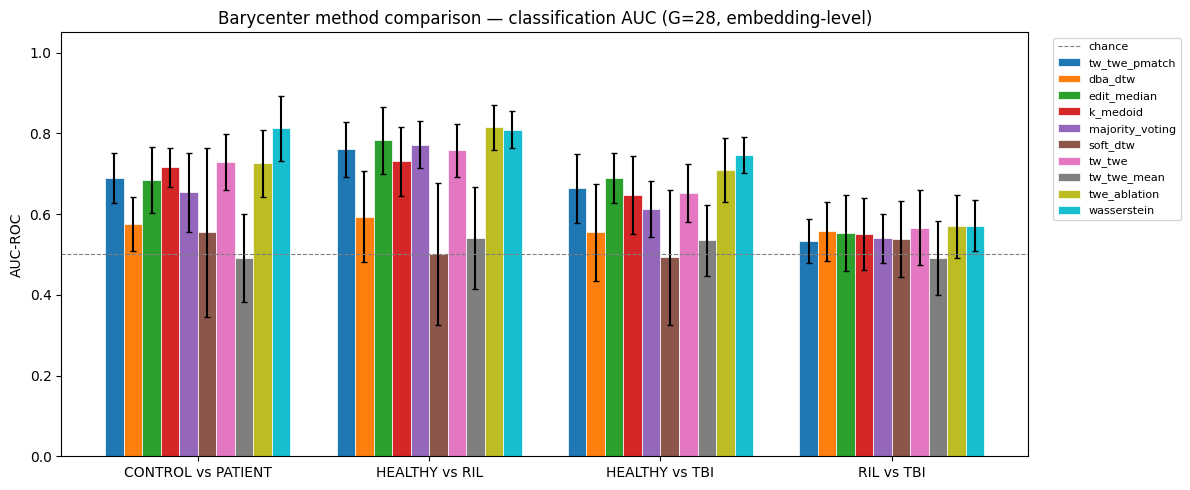

In [ ]:
# Grouped bar chart: AUC by method and comparison pair (G=28 faithful)
auc_summary = (
    df_all.groupby(['method', 'comparison'])['auc']
    .agg(['mean', 'std'])
    .reset_index()
)

# Order: proposed first, then the rest alphabetically
method_order = ['tw_twe_pmatch'] + sorted([m for m in df_all['method'].unique() if m != 'tw_twe_pmatch'])
comparison_order = sorted(df_all['comparison'].unique())

fig, ax = plt.subplots(figsize=(12, 5))
n_methods = len(method_order)
n_comparisons = len(comparison_order)
bar_width = 0.8 / n_methods
colors = plt.cm.tab10(np.linspace(0, 1, n_methods))

for mi, method in enumerate(method_order):
    means, stds, xs = [], [], []
    for ci, comp in enumerate(comparison_order):
        row = auc_summary[(auc_summary['method'] == method) & (auc_summary['comparison'] == comp)]
        means.append(row['mean'].values[0] if len(row) else 0)
        stds.append(row['std'].values[0] if len(row) else 0)
        xs.append(ci + mi * bar_width)
    ax.bar(xs, means, bar_width, yerr=stds, label=method, color=colors[mi],
           edgecolor='white', linewidth=0.5, capsize=2)

ax.set_xticks([ci + (n_methods - 1) * bar_width / 2 for ci in range(n_comparisons)])
ax.set_xticklabels([c.replace('_', ' ') for c in comparison_order])
ax.set_ylabel('AUC-ROC')
ax.set_title('Barycenter method comparison — classification AUC (G=28, embedding-level)')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylim(0, 1.05)
fig.tight_layout()

fig.savefig(os.path.join(out_dir, 'g28_auc_bars.png'), dpi=150, bbox_inches='tight')
print(f"Saved: {os.path.join(out_dir, 'g28_auc_bars.png')}")
plt.show()


### Barycenter chronograms (faithful, full-length)

Example barycenters per group per method, computed on split-0 training data at the **full
embedding length** (rendered at width `FIG_L=1500`; the underlying sequences are L≈5162, not a
short resample). Shown for the full-length-tractable methods; the pure-Python DTW previews are
omitted here (they appear in the table with their gated `L`). Wasserstein produces a histogram
rather than a sequence and is shown separately. All panels share one G=28 symbol colormap.

Saved: /home/perochon/data-gold-final/outputs/symbolic_barycenter/g28/g28_chronograms.png


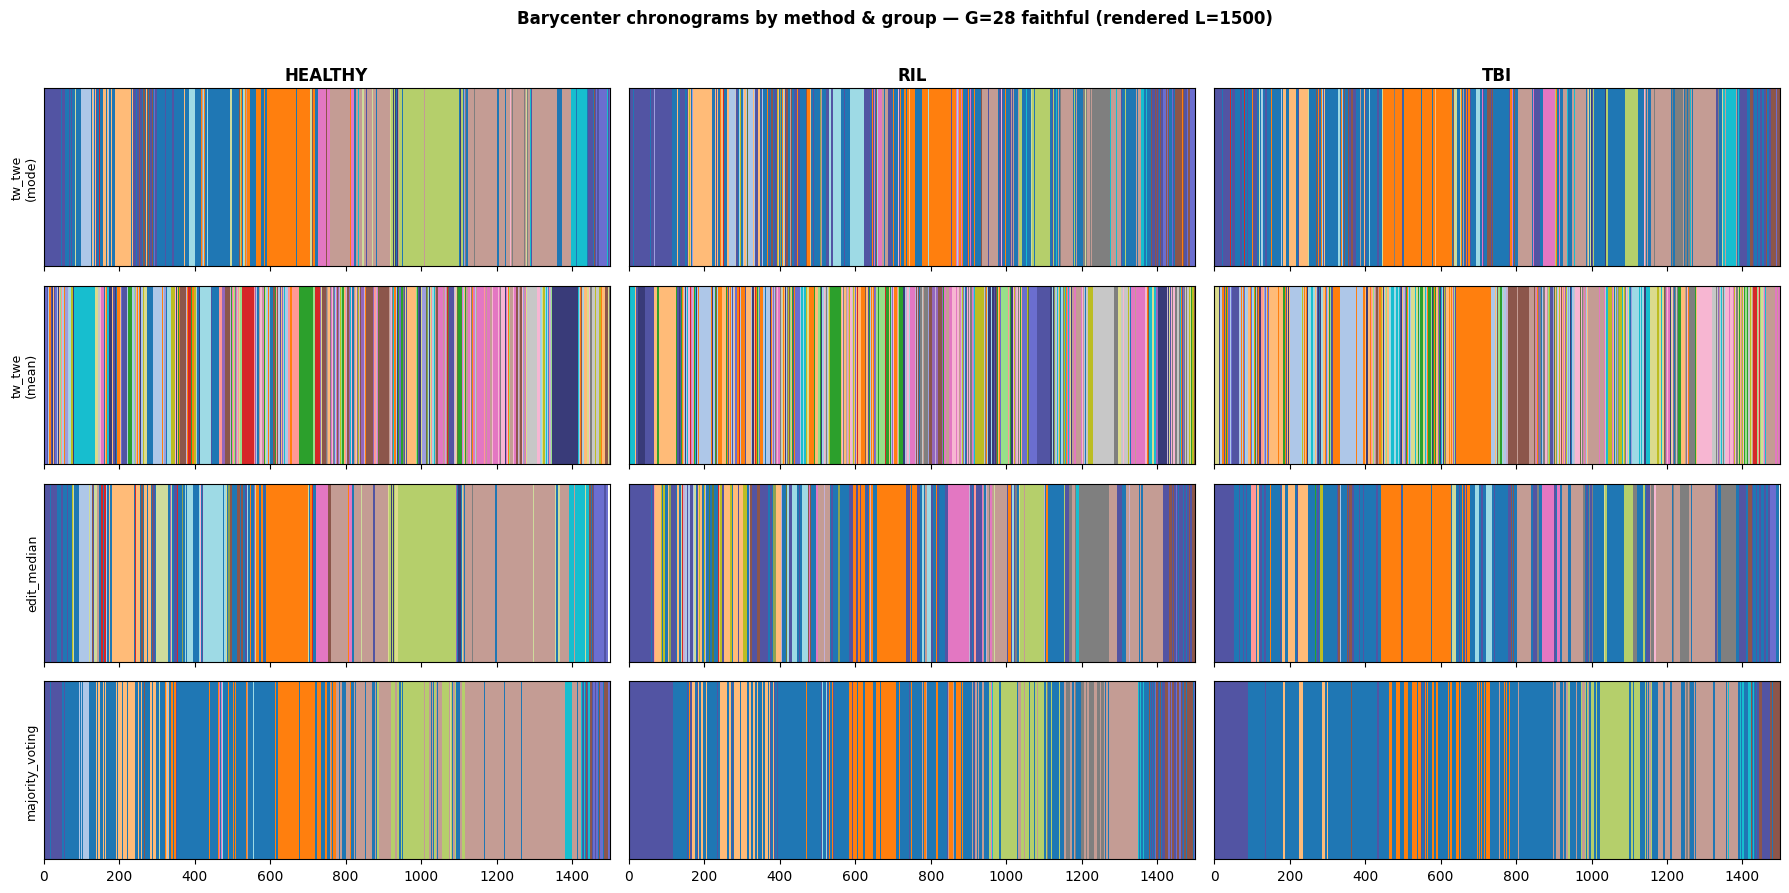

Saved: /home/perochon/data-gold-final/outputs/symbolic_barycenter/g28/baseline_wasserstein_histograms.png


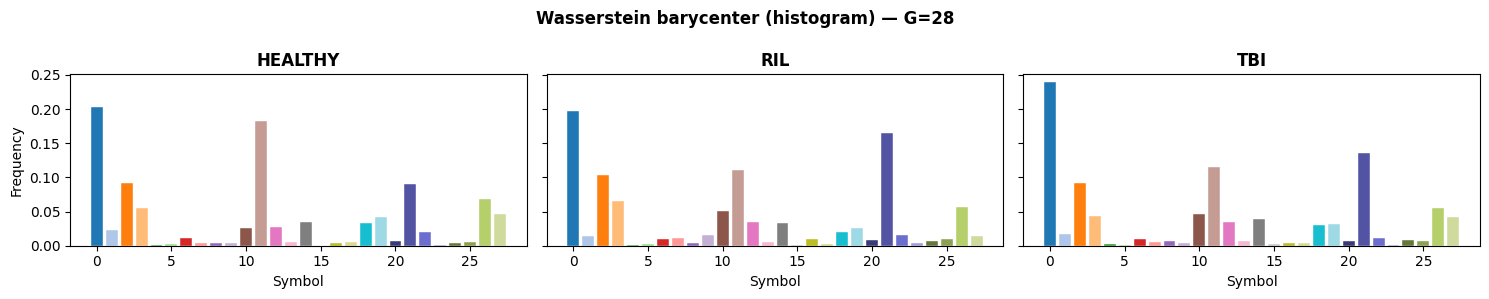

In [ ]:
# Example barycenters per group per method (split 0, seed 42), at full length, rendered at FIG_L.
splitter_ex = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
train_idx_ex, _ = next(splitter_ex.split(np.zeros(len(labels)), labels))
seed = 42
X_fig = Xat(FIG_L)

groups = sorted(np.unique(labels))
sym_colors = get_base_colors(G)
cmap = ListedColormap(sym_colors)
norm = BoundaryNorm(np.arange(-0.5, G + 0.5), cmap.N)

seq_methods = {
    'tw_twe (mode)':   lambda X: build_mode(X, seed),
    'tw_twe (mean)':   lambda X: build_mean(X, seed),
    'edit_median':     lambda X: barycenter_edit_median(X, n_alphabet=G),
    'majority_voting': lambda X: barycenter_majority_voting(X),
}

fig, axes = plt.subplots(len(seq_methods), len(groups),
                         figsize=(18, 2.2 * len(seq_methods)), sharex=True, squeeze=False)
for mi, (mname, mfn) in enumerate(seq_methods.items()):
    for gi, grp in enumerate(groups):
        Xg = X_fig[train_idx_ex][labels[train_idx_ex] == grp]
        b = np.asarray(mfn(Xg)).squeeze().astype(int)
        axes[mi, gi].imshow(b[np.newaxis, :], aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')
        axes[mi, gi].set_yticks([])
        if mi == 0:
            axes[mi, gi].set_title(grp, fontweight='bold')
        if gi == 0:
            axes[mi, gi].set_ylabel(mname.replace(' ', '\n'), fontsize=9)
fig.suptitle(f'Barycenter chronograms by method & group — G=28 faithful (rendered L={FIG_L})',
             fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(out_dir, 'g28_chronograms.png'), dpi=150, bbox_inches='tight')
print(f"Saved: {os.path.join(out_dir, 'g28_chronograms.png')}")
plt.show()

# Wasserstein barycenter = histogram (length-invariant); same symbol -> same color as chronograms.
fig_w, axes_w = plt.subplots(1, len(groups), figsize=(15, 3), sharey=True, squeeze=False)
for gi, grp in enumerate(groups):
    Xg = X_fig[train_idx_ex][labels[train_idx_ex] == grp]
    h = barycenter_wasserstein(Xg, D_G)
    axes_w[0, gi].bar(range(G), h, color=sym_colors, edgecolor='white', linewidth=0.3)
    axes_w[0, gi].set_title(grp, fontweight='bold'); axes_w[0, gi].set_xlabel('Symbol')
    if gi == 0:
        axes_w[0, gi].set_ylabel('Frequency')
fig_w.suptitle('Wasserstein barycenter (histogram) — G=28', fontweight='bold')
fig_w.tight_layout()
fig_w.savefig(os.path.join(out_dir, 'baseline_wasserstein_histograms.png'), dpi=150, bbox_inches='tight')
print(f"Saved: {os.path.join(out_dir, 'baseline_wasserstein_histograms.png')}")
plt.show()


Saved: /home/perochon/data-gold-final/outputs/symbolic_barycenter/g28/g28_DGcat_heatmap.png


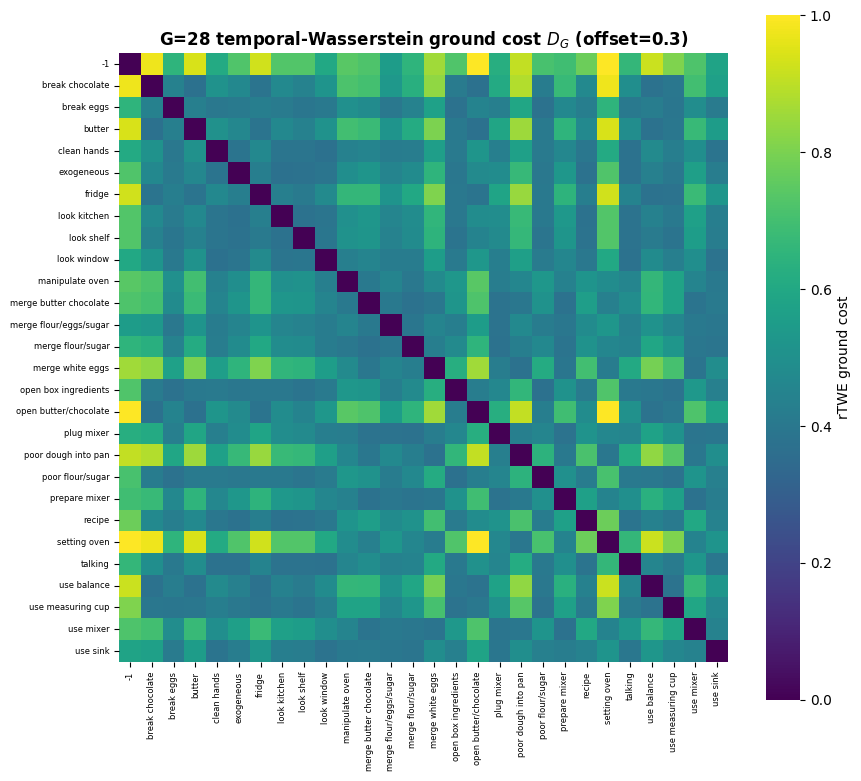

Saved: /home/perochon/data-gold-final/outputs/symbolic_barycenter/g28/g28_category_frequency_by_group.png


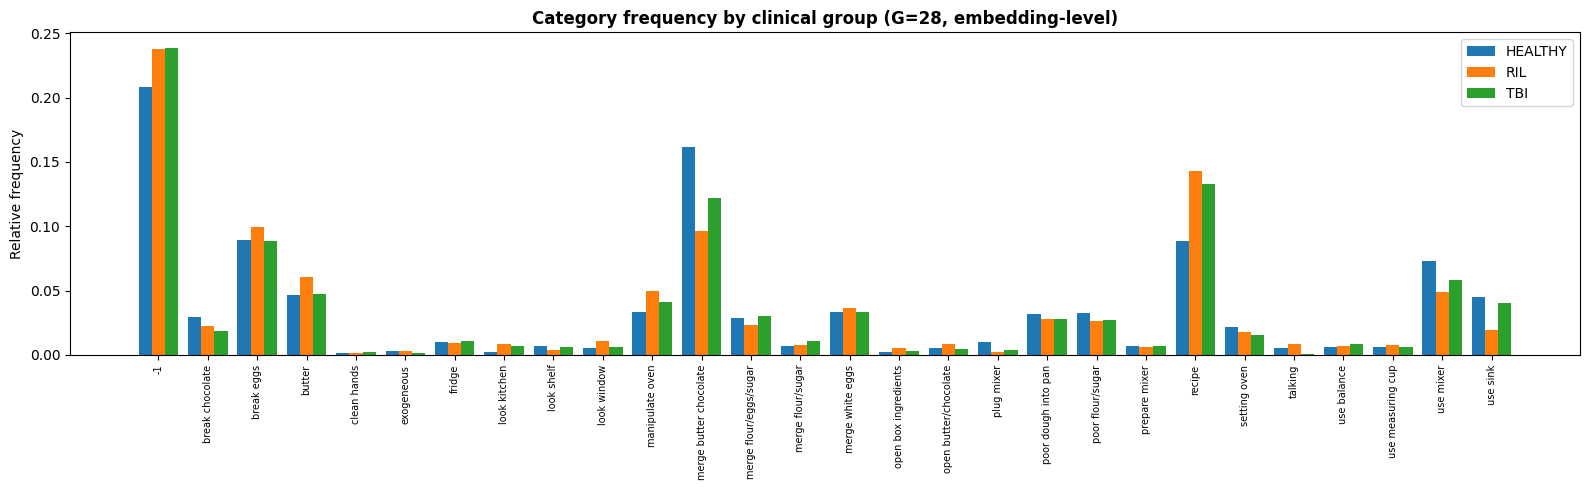

In [ ]:
# Companion figures: rTWE ground cost D_G + category frequency by clinical group.
code_to_label = [None] * G
for k, v in code.items():
    code_to_label[v] = k

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(D_G, cmap='viridis', square=True, cbar_kws={'label': 'rTWE ground cost'},
            xticklabels=code_to_label, yticklabels=code_to_label, ax=ax)
ax.set_title(f'G=28 temporal-Wasserstein ground cost $D_G$ (offset={OFFSET})', fontweight='bold')
ax.tick_params(labelsize=6)
fig.tight_layout()
fig.savefig(os.path.join(out_dir, 'g28_DGcat_heatmap.png'), dpi=150, bbox_inches='tight')
print(f"Saved: {os.path.join(out_dir, 'g28_DGcat_heatmap.png')}")
plt.show()

# Category frequency by group — supports the "frequency-style features lead" reframe (length-invariant).
freq = np.zeros((len(groups), G))
for gi, grp in enumerate(groups):
    seqs = [np.asarray(s) for s, l in zip(X_full, labels) if l == grp]
    counts = np.bincount(np.concatenate(seqs), minlength=G).astype(float)
    freq[gi] = counts / counts.sum()

fig, ax = plt.subplots(figsize=(16, 5))
xpos = np.arange(G); w = 0.8 / len(groups)
for gi, grp in enumerate(groups):
    ax.bar(xpos + gi * w, freq[gi], w, label=grp)
ax.set_xticks(xpos + w * (len(groups) - 1) / 2)
ax.set_xticklabels(code_to_label, rotation=90, fontsize=7)
ax.set_ylabel('Relative frequency')
ax.set_title('Category frequency by clinical group (G=28, embedding-level)', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(out_dir, 'g28_category_frequency_by_group.png'), dpi=150, bbox_inches='tight')
print(f"Saved: {os.path.join(out_dir, 'g28_category_frequency_by_group.png')}")
plt.show()


In [ ]:
# Save comparison results + significance + budget metadata (G=28 lineage, g28/ dir).
df_all.to_csv(os.path.join(out_dir, 'baseline_comparison_g28.csv'), index=False)
df_sig.to_csv(os.path.join(out_dir, 'baseline_significance_g28.csv'), index=False)
with open(os.path.join(out_dir, 'baseline_budget.json'), 'w') as f:
    json.dump({
        'G': int(G), 'nu': NU, 'lmbda': LMBDA, 'offset': OFFSET,
        'full_len': int(FULL_L), 'fig_len': int(FIG_L),
        'tier_b_protocol': {'n_splits': int(sp), 'n_inits': int(ni), 'L': int(L_B)},
        'preview_protocol': {'n_splits': PREVIEW_SPLITS, 'n_inits': PREVIEW_INITS},
        'preview_gate': gate, 'reference': 'tw_twe_pmatch', 'quick_mode': bool(QUICK_MODE),
        'method_lengths': {m: int(df_all[df_all.method == m]['L'].max()) for m in sorted(df_all.method.unique())},
    }, f, indent=2)

print(f"Saved: baseline_comparison_g28.csv ({len(df_all)} rows, {df_all['method'].nunique()} methods)")
print(f"Saved: baseline_significance_g28.csv ({len(df_sig)} rows)")
print(f"Saved: baseline_budget.json")

print("\n=== Significant differences (proposed vs baseline, BH-corrected) ===")
sig = df_sig[df_sig['significant']].copy()
if len(sig):
    display(sig[['method', 'comparison', 'mean_auc', 'ref_mean_auc', 'delta', 'p_value_bh']].round(4))
else:
    print("None reached BH-corrected significance at alpha=0.05.")


Saved: baseline_comparison_g28.csv (1040 rows, 10 methods)
Saved: baseline_significance_g28.csv (36 rows)
Saved: baseline_budget.json

=== Significant differences (proposed vs baseline, BH-corrected) ===


,method,comparison,mean_auc,ref_mean_auc,delta,p_value_bh
6,tw_twe_mean,CONTROL_vs_PATIENT,0.4912,0.6899,0.1987,0.0141
9,dba_dtw,HEALTHY_vs_RIL,0.5933,0.7604,0.1671,0.0141
13,soft_dtw,HEALTHY_vs_RIL,0.5002,0.7604,0.2601,0.0141
15,tw_twe_mean,HEALTHY_vs_RIL,0.5406,0.7604,0.2197,0.0141
24,tw_twe_mean,HEALTHY_vs_TBI,0.5345,0.6633,0.1289,0.0352
26,wasserstein,HEALTHY_vs_TBI,0.7461,0.6633,-0.0828,0.0141
